# Analysis of Residual Stream Activation Vectors (Raw + Deconfounded)

**Input files**:
- `INPUT_FILE` — a single `.pt` reasoning-vectors file produced by `run_fw_pass.py --type reasoning` with an additional deconfounding of the reasoning vectors with the pirncipal components of a chosen baseline dataset. Each layer contains:
  - `mean_correct_token`: global average of every correct reasoning token `[d_model]`
  - `mean_incorrect_token`: global average of every incorrect reasoning token `[d_model]`
  - `reasoning_direction_token`: `mean_correct_token - mean_incorrect_token` `[d_model]`
  - `per_sample_means`: per-sample average activation `[N_samples, d_model]`
  - `mean_correct_samples`: mean activation of perfectly-correct samples `[d_model]`
  - `mean_incorrect_samples`: mean activation of flawed samples `[d_model]`
  - `reasoning_direction_sample`: `mean_correct_samples - mean_incorrect_samples` `[d_model]`
  - `reasoning_direction_token_cleaned`: `reasoning_direction_token` deconfounded with chosen baseline
  - `reasoning_direction_sample_cleaned`: `reasoning_direction_sample` deconfounded with chosen baseline

**Analysis done**:
- Token and sample level (cosine) similarity of activations for reasoning (ProcessBench) dataset
- Unsupervised clustering method (Principal component analysis) for per-sample activation means
- Overlap of reasoning vectors with baseline principal components

## Set-up

In [20]:
!pip install matplotlib seaborn scikit-learn numpy torch --quiet

In [21]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
import math
import copy
from sklearn.decomposition import PCA
from pathlib import Path

sns.set_theme(style="whitegrid")

In [22]:
# ── File paths ────────────────────────────────────────────────────────────────
# RAW AND DE-CONFOUNDED REASONING VECTORS FOR DIFF BASELINE DATASETS
INPUT_FILE_CLEANED_VECTORS_FINEWEB = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_fineweb.pt"
INPUT_FILE_CLEANED_VECTORS_DEEPMIND_MATH = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_deepmind_math.pt"
INPUT_FILE_CLEANED_VECTORS_JOINT_FINEWEB_DEEPMIND_MATH = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/processbench/reasoning_vectors_cleaned_joint_fineweb_deepmind_math.pt"

# PCA COMPONENTS OF BASELINE DATASET
BASELINE_PCA_FILE_FINEWEB = "/home/ines/Reasoning-activations/reasoning_vectors/Qwen3-8B/fineweb_pca_components.pt"     
BASELINE_PCA_FILE_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/deepmind_math_pca_components_20000samples.pt"
BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH = "/home/ines/Reasoning-activations/baseline_vectors/Qwen3-8B/joint_pca_fineweb_deepmind_40000samples.pt"


INPUT_FILE_CLEANED_VECTORS = INPUT_FILE_CLEANED_VECTORS_JOINT_FINEWEB_DEEPMIND_MATH
BASELINE_PCA = BASELINE_PCA_FILE_JOINT_FINEWEB_DEEPMIND_MATH

# the cleaned vectors baseline dataset must correspond with chosen baseline_pca file!!!

# 1. Extract components using pathlib
file_path = Path(INPUT_FILE_CLEANED_VECTORS)
path_parts = file_path.parts

# Find the index of 'reasoning_vectors' to relative-reference the next folders
rv_idx = path_parts.index("reasoning_vectors")
model_name = path_parts[rv_idx + 1]
reasoning_dataset = path_parts[rv_idx + 2]

# Extract baseline_dataset by removing prefix and suffix from the filename
baseline_dataset = file_path.stem.replace("reasoning_vectors_cleaned_", "")

# 2. Define output directory and ensure it exists
out_dir = Path(f"/home/ines/Reasoning-activations/results/reasoning_vector_analysis/{model_name}/{reasoning_dataset}")
out_dir.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────

## Load input file

In [23]:
data = torch.load(INPUT_FILE_CLEANED_VECTORS, map_location="cpu")

meta   = data["metadata"]
layers = data["layers"]

# Sort layer names by their integer index (e.g. "blocks.18.hook_out" → 18)
sorted_layer_names = sorted(
    layers.keys(),
    key=lambda x: int(x.split(".")[1])
)

# Per-sample correctness mask
is_perfect_mask = meta["per_sample_is_fully_correct"]   # bool tensor [N_samples]
y_mask          = is_perfect_mask.numpy()

print(f"Model          : {meta.get('model', 'N/A')}")
print(f"Target layers  : {meta.get('target_layers', 'N/A')}")
print(f"Correct tokens : {meta.get('count_correct_tokens', 'N/A')}")
print(f"Incorrect toks : {meta.get('count_incorrect_tokens', 'N/A')}")
print(f"Perfect samples: {is_perfect_mask.sum().item()}")
print(f"Flawed samples : {(~is_perfect_mask).sum().item()}")
print(f"Layers found   : {sorted_layer_names}")

Model          : Qwen/Qwen3-8B
Target layers  : [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
Correct tokens : 1209005
Incorrect toks : 1083086
Perfect samples: 1178
Flawed samples : 2218
Layers found   : ['blocks.18.hook_out', 'blocks.19.hook_out', 'blocks.20.hook_out', 'blocks.21.hook_out', 'blocks.22.hook_out', 'blocks.23.hook_out', 'blocks.24.hook_out', 'blocks.25.hook_out', 'blocks.26.hook_out', 'blocks.27.hook_out', 'blocks.28.hook_out']


## Layer statistics - Token and sample level (cosine) similarity

- **Token-level cosine similarity**: angle between the global-average correct-token vector and the global-average incorrect-token vector. Values close to 1 indicate the model's activation is in roughly the same direction for both classes — most of the vector's "volume" is shared language-modeling signal.
- **Sample-level cosine similarity**: same idea but for the per-sample means (one vector per problem, averaged within each class).
- **Steering vector magnitude**: L2 norm of `reasoning_direction_token / reasoning_direction_sample` — the absolute geometric distance between the two class centres.

Identical results no matter the baseline dataset

=== Layer Statistics ===
  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.995433
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.993951
  Cosine Sim (Token Dir vs Sample Dir): 0.721687
  Token  Steering Vec Magnitude: 7.4717
  Sample Steering Vec Magnitude: 9.1812
Layer blocks.18.hook_out  |  token: 0.9954  |  sample: 0.9940  |  alignment: 0.7217
  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.993901
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.994053
  Cosine Sim (Token Dir vs Sample Dir): 0.706868
  Token  Steering Vec Magnitude: 9.8716
  Sample Steering Vec Magnitude: 10.2663
Layer blocks.19.hook_out  |  token: 0.9939  |  sample: 0.9941  |  alignment: 0.7069
  Token-Level  Cosine Sim  (Correct vs Incorrect): 0.993841
  Sample-Level Cosine Sim  (Perfect vs Flawed):    0.994051
  Cosine Sim (Token Dir vs Sample Dir): 0.688282
  Token  Steering Vec Magnitude: 10.1103
  Sample Steering Vec Magnitude: 10.4292
Layer blocks.20.hook_out  |  token: 0.9938  |  sample: 0.

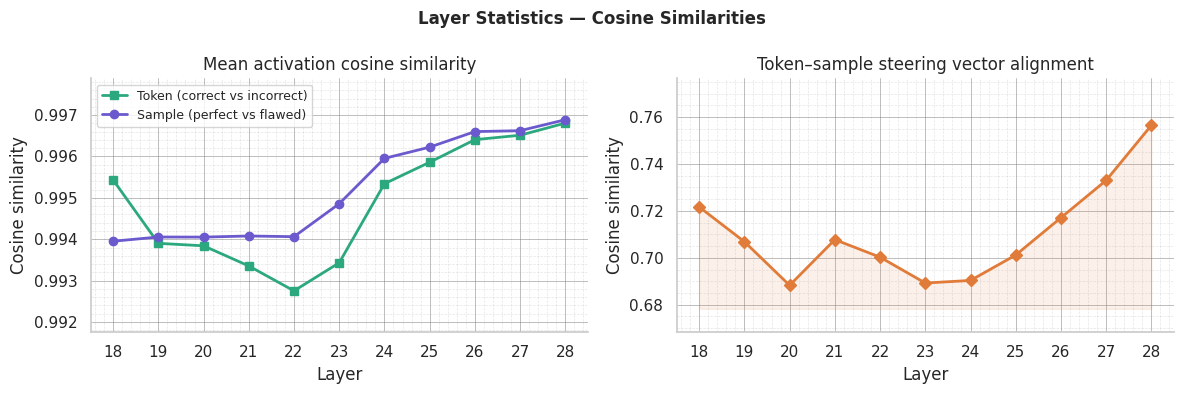

In [24]:
print("=== Layer Statistics ===")

sorted_layer_names = sorted(layers.keys())
layer_indices = [int(name.split(".")[1]) for name in sorted_layer_names]

token_cos_sim, sample_cos_sim, tok_samp_sim = [], [], []

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    token_sim = F.cosine_similarity(
        ld["mean_correct_token"].unsqueeze(0),
        ld["mean_incorrect_token"].unsqueeze(0)
    ).item()
    print(f"  Token-Level  Cosine Sim  (Correct vs Incorrect): {token_sim:.6f}")

    sample_sim = F.cosine_similarity(
        ld["mean_correct_samples"].unsqueeze(0),
        ld["mean_incorrect_samples"].unsqueeze(0)
    ).item()
    print(f"  Sample-Level Cosine Sim  (Perfect vs Flawed):    {sample_sim:.6f}")


    alignment = F.cosine_similarity(
        ld["reasoning_direction_token"].unsqueeze(0),
        ld["reasoning_direction_sample"].unsqueeze(0)
    ).item()
    print(f"  Cosine Sim (Token Dir vs Sample Dir): {alignment:.6f}")

    # Steering vector magnitudes
    token_mag  = torch.norm(ld["reasoning_direction_token"]).item()
    sample_mag = torch.norm(ld["reasoning_direction_sample"]).item()
    print(f"  Token  Steering Vec Magnitude: {token_mag:.4f}")
    print(f"  Sample Steering Vec Magnitude: {sample_mag:.4f}")

    token_cos_sim.append(token_sim)
    sample_cos_sim.append(sample_sim)
    tok_samp_sim.append(alignment)

    print(f"Layer {layer_name}  |  token: {token_sim:.4f}  |  sample: {sample_sim:.4f}  |  alignment: {alignment:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────
PURPLE, GREEN, ORANGE = "#6a5acd", "#2ca87f", "#e07b39"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Layer Statistics — Cosine Similarities", fontsize=12, fontweight="bold")

ax1.plot(layer_indices, token_cos_sim,  "s-", color=GREEN,  lw=2, label="Token (correct vs incorrect)")
ax1.plot(layer_indices, sample_cos_sim, "o-", color=PURPLE, lw=2, label="Sample (perfect vs flawed)")
ax1.set_title("Mean activation cosine similarity")
ax1.set_ylabel("Cosine similarity")
ax1.set_ylim(min(token_cos_sim + sample_cos_sim) - 0.001,
             max(token_cos_sim + sample_cos_sim) + 0.001)
ax1.legend(fontsize=9)

ax2.plot(layer_indices, tok_samp_sim, "D-", color=ORANGE, lw=2)
ax2.fill_between(layer_indices, tok_samp_sim,
                 min(tok_samp_sim) - 0.01, color=ORANGE, alpha=0.1)
ax2.set_title("Token–sample steering vector alignment")
ax2.set_ylabel("Cosine similarity")
ax2.set_ylim(min(tok_samp_sim) - 0.02, max(tok_samp_sim) + 0.02)

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(layer_indices)
    # Turn on minor ticks for more granular y-axis markers
    ax.minorticks_on()

    # Make the grid much more visible with contrasting major/minor lines
    ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
    ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
    
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
# plt.savefig("/home/ines/Reasoning-activations/results/reasoning_vector_analysis/layer_cosine_similarities.png", dpi=150, bbox_inches="tight")
plt.savefig(out_dir / f"layer_cosine_similarities.png", dpi=150, bbox_inches="tight")
plt.show()

- Calculate the cosine similarity between correct and incorrect reasoning vectors across all targeted layers. If the similarity is low, it suggests the model is in a distinctly different state when hallucinating / incorrectly reasoning versus when reasoning correctly.
- interesting to see cosine similarity with average vector on baseline dataset, layer wise?

## Load baseline PCA components

In [25]:
baseline_pca = torch.load(BASELINE_PCA, map_location="cpu")
pca_by_layer = baseline_pca["layers"]   # keys are int layer indices
    
def get_baseline_components(layer_name: str):
    """
    Look up PCA components for a layer whose name is e.g. 'blocks.18.hook_out'.
    This unified version supports dictionaries with either string keys or integer keys.
    Returns a numpy array of shape [n_components, d_model].
    """
    # Option 1: The dictionary uses the exact string as the key
    if layer_name in pca_by_layer:
        return pca_by_layer[layer_name].to(torch.float32).numpy()
    
    # Option 2: The dictionary uses integer keys (fallback)
    try:
        layer_idx = int(layer_name.split(".")[1])
        return pca_by_layer[layer_idx].to(torch.float32).numpy()
    except (IndexError, ValueError) as e:
        raise KeyError(f"Could not find key '{layer_name}' or its integer index in pca_by_layer.") from e
    
def project_out_components(vec: torch.Tensor, components: np.ndarray) -> torch.Tensor:
    """
    Project out a set of (orthogonal, unit-norm) PCA components from a vector.
    Works for both 1-D vectors [d_model] and 2-D matrices [N, d_model].
    """
    x = vec.to(torch.float32).numpy().copy()
    original_shape = x.shape
    if x.ndim == 1:
        x = x.reshape(1, -1)
    for comp in components:                              # comp: [d_model]
        projection = x @ comp                           # [N]
        x -= projection[:, None] * comp[None, :]        # subtract component
    return torch.tensor(x.reshape(original_shape), dtype=vec.dtype)


print("Baseline PCA file loaded.")
print(f"Layers in baseline file: {list(pca_by_layer.keys())}")

Baseline PCA file loaded.
Layers in baseline file: [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


## Compute overlap of (original) reasoning vectors with the baseline subspace
Compute the percentage of the original reasoning direction vector's magnitude that is captured by (or "lies within") the Principal Component (PCA) subspace of the baseline dataset.


We subtract the projection of each steering vector onto the basline PC subspace. This removes variance that is shared with generic language processing, leaving a cleaner signal that is more specific to the *correctness* of mathematical reasoning.



=== Projecting out baseline PCA components ===
Layer blocks.18.hook_out  (3 components)  |  token: 7.472→6.250 (54.8%)  |  sample: 9.181→5.247 (82.1%)
Layer blocks.19.hook_out  (3 components)  |  token: 9.872→8.503 (50.8%)  |  sample: 10.266→6.563 (76.9%)
Layer blocks.20.hook_out  (3 components)  |  token: 10.110→9.129 (43.0%)  |  sample: 10.429→7.437 (70.1%)
Layer blocks.21.hook_out  (3 components)  |  token: 11.580→10.436 (43.3%)  |  sample: 11.680→8.265 (70.7%)
Layer blocks.22.hook_out  (3 components)  |  token: 13.497→12.601 (35.8%)  |  sample: 12.988→10.210 (61.8%)
Layer blocks.23.hook_out  (3 components)  |  token: 15.667→15.400 (18.4%)  |  sample: 14.263→12.924 (42.3%)
Layer blocks.24.hook_out  (4 components)  |  token: 17.630→17.541 (10.0%)  |  sample: 16.461→16.121 (20.2%)
Layer blocks.25.hook_out  (4 components)  |  token: 18.801→18.549 (16.3%)  |  sample: 17.944→17.770 (13.9%)
Layer blocks.26.hook_out  (3 components)  |  token: 20.597→20.235 (18.7%)  |  sample: 19.951→19.709

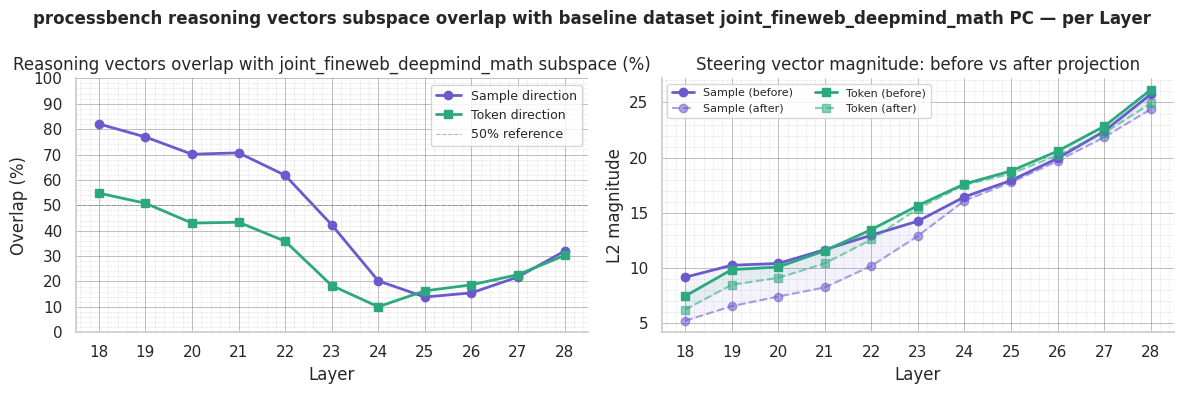

In [26]:
print("=== Projecting out baseline PCA components ===")

token_overlap_pct, sample_overlap_pct = [], []
token_mag_before,  token_mag_after    = [], []
sample_mag_before, sample_mag_after   = [], []
valid_layer_indices = []

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    try:
        components = get_baseline_components(layer_name)
    except KeyError as e:
        print(f"  WARNING: {e}. Skipping layer.")
        continue

    n_comp = components.shape[0]

    rd_token  = ld["reasoning_direction_token"]
    rd_sample = ld["reasoning_direction_sample"]
    rd_token_cleaned = ld["reasoning_direction_token_cleaned"]
    rd_sample_cleaned = ld["reasoning_direction_sample_cleaned"]

    orig_token_mag   = torch.norm(rd_token).item()
    clean_token_mag  = torch.norm(rd_token_cleaned).item()
    orig_sample_mag  = torch.norm(rd_sample).item()
    clean_sample_mag = torch.norm(rd_sample_cleaned).item()

    dot_token  = torch.tensor(np.array([
        np.dot(rd_token.to(torch.float32).numpy()  / (orig_token_mag  + 1e-12), c)
        for c in components]))
    dot_sample = torch.tensor(np.array([
        np.dot(rd_sample.to(torch.float32).numpy() / (orig_sample_mag + 1e-12), c)
        for c in components]))

    overlap_token  = torch.sqrt((dot_token**2).sum()).item()
    overlap_sample = torch.sqrt((dot_sample**2).sum()).item()

    token_overlap_pct.append(overlap_token   * 100)
    sample_overlap_pct.append(overlap_sample * 100)
    token_mag_before.append(orig_token_mag);   token_mag_after.append(clean_token_mag)
    sample_mag_before.append(orig_sample_mag); sample_mag_after.append(clean_sample_mag)
    valid_layer_indices.append(int(layer_name.split(".")[1]))

    print(f"Layer {layer_name}  ({n_comp} components)  |  "
          f"token: {orig_token_mag:.3f}→{clean_token_mag:.3f} ({overlap_token*100:.1f}%)  |  "
          f"sample: {orig_sample_mag:.3f}→{clean_sample_mag:.3f} ({overlap_sample*100:.1f}%)")

print("\n=== Projection complete ===")

# ── Plot ──────────────────────────────────────────────────────────────────
PURPLE, GREEN = "#6a5acd", "#2ca87f"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"{reasoning_dataset} reasoning vectors subspace overlap with baseline dataset {baseline_dataset} PC — per Layer", fontsize=12, fontweight="bold")

# Left: overlap %
ax1.plot(valid_layer_indices, sample_overlap_pct, "o-", color=PURPLE, lw=2, label="Sample direction")
ax1.plot(valid_layer_indices, token_overlap_pct,  "s-", color=GREEN,  lw=2, label="Token direction")
ax1.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.6, label="50% reference")
ax1.set_title(f"Reasoning vectors overlap with {baseline_dataset} subspace (%)")
ax1.set_ylabel("Overlap (%)")
ax1.set_ylim(0, 100)
# Put explicit major ticks every 10% on the y-axis
ax1.set_yticks(range(0, 101, 10)) 
ax1.legend(fontsize=9)

# Right: magnitude before vs after
ax2.plot(valid_layer_indices, sample_mag_before, "o-",  color=PURPLE, lw=2,   label="Sample (before)")
ax2.plot(valid_layer_indices, sample_mag_after,  "o--", color=PURPLE, lw=1.5, alpha=0.55, label="Sample (after)")
ax2.plot(valid_layer_indices, token_mag_before,  "s-",  color=GREEN,  lw=2,   label="Token (before)")
ax2.plot(valid_layer_indices, token_mag_after,   "s--", color=GREEN,  lw=1.5, alpha=0.55, label="Token (after)")
ax2.fill_between(valid_layer_indices, sample_mag_after, sample_mag_before, color=PURPLE, alpha=0.07)
ax2.fill_between(valid_layer_indices, token_mag_after,  token_mag_before,  color=GREEN,  alpha=0.07)
ax2.set_title("Steering vector magnitude: before vs after projection")
ax2.set_ylabel("L2 magnitude")
ax2.legend(fontsize=8, ncol=2)

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(valid_layer_indices)
    
    # Turn on minor ticks for more granular y-axis markers
    ax.minorticks_on()
    
    # Make the grid much more visible with contrasting major/minor lines
    ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
    ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
    
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / f"overlap_projection_{baseline_dataset}.png", dpi=150, bbox_inches="tight")
plt.show()

=== Projecting out baseline PCA components ===
Layer blocks.18.hook_out  (3 components)  |  token: 7.472→6.250 (54.8%)  |  sample: 9.181→5.247 (82.1%)
Layer blocks.19.hook_out  (3 components)  |  token: 9.872→8.503 (50.8%)  |  sample: 10.266→6.563 (76.9%)
Layer blocks.20.hook_out  (3 components)  |  token: 10.110→9.129 (43.0%)  |  sample: 10.429→7.437 (70.1%)
Layer blocks.21.hook_out  (3 components)  |  token: 11.580→10.436 (43.3%)  |  sample: 11.680→8.265 (70.7%)
Layer blocks.22.hook_out  (3 components)  |  token: 13.497→12.601 (35.8%)  |  sample: 12.988→10.210 (61.8%)
Layer blocks.23.hook_out  (3 components)  |  token: 15.667→15.400 (18.4%)  |  sample: 14.263→12.924 (42.3%)
Layer blocks.24.hook_out  (4 components)  |  token: 17.630→17.541 (10.0%)  |  sample: 16.461→16.121 (20.2%)
Layer blocks.25.hook_out  (4 components)  |  token: 18.801→18.549 (16.3%)  |  sample: 17.944→17.770 (13.9%)
Layer blocks.26.hook_out  (3 components)  |  token: 20.597→20.235 (18.7%)  |  sample: 19.951→19.709

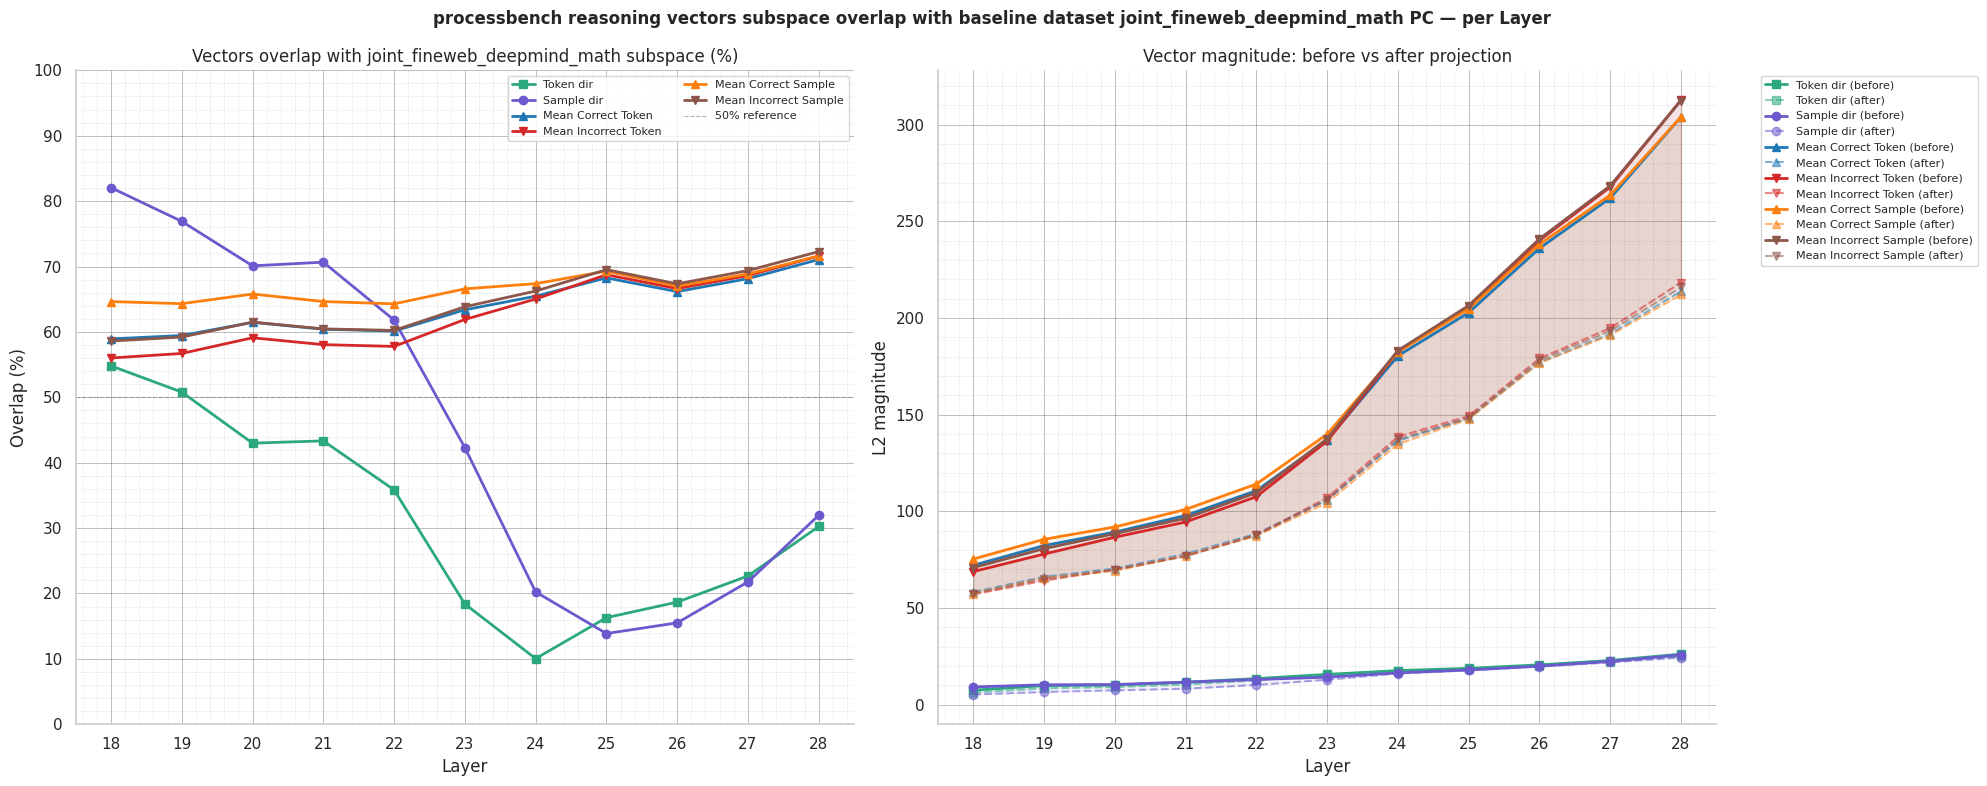

In [27]:
print("=== Projecting out baseline PCA components ===")

# 1. Setup keys for the 6 target vectors we are analyzing
keys = ["rd_token", "rd_sample", "mct", "mit", "mcs", "mis"]

# 2. Data dictionary to store metrics cleanly without 18 different list variables
data = {
    "overlap_pct": {k: [] for k in keys},
    "mag_before":  {k: [] for k in keys},
    "mag_after":   {k: [] for k in keys}
}
valid_layer_indices = []

# Helper function to prevent redundant overlap calculation code
def get_overlap(vec, orig_mag, comps):
    vec_np = vec.to(torch.float32).numpy()
    dot_vals = torch.tensor(np.array([
        np.dot(vec_np / (orig_mag + 1e-12), c) for c in comps
    ]))
    return torch.sqrt((dot_vals**2).sum()).item()

for layer_name in sorted_layer_names:
    ld = layers[layer_name]

    try:
        components = get_baseline_components(layer_name)
    except KeyError as e:
        print(f"  WARNING: {e}. Skipping layer.")
        continue

    n_comp = components.shape[0]

    # Extract all 6 baseline/reasoning vectors
    vecs = {
        "rd_token":  ld["reasoning_direction_token"],
        "rd_sample": ld["reasoning_direction_sample"],
        "mct":       ld["mean_correct_token"],
        "mit":       ld["mean_incorrect_token"],
        "mcs":       ld["mean_correct_samples"],
        "mis":       ld["mean_incorrect_samples"]
    }
    
    # Extract pre-cleaned or dynamically project out components for the 4 new ones
    vecs_cleaned = {
        "rd_token":  ld["reasoning_direction_token_cleaned"],
        "rd_sample": ld["reasoning_direction_sample_cleaned"],
        "mct":       project_out_components(vecs["mct"], components),
        "mit":       project_out_components(vecs["mit"], components),
        "mcs":       project_out_components(vecs["mcs"], components),
        "mis":       project_out_components(vecs["mis"], components)
    }

    log_strs = []
    # Compute everything in a simple loop over the 6 keys
    for k in keys:
        orig_mag = torch.norm(vecs[k]).item()
        clean_mag = torch.norm(vecs_cleaned[k]).item()
        overlap = get_overlap(vecs[k], orig_mag, components)
        
        data["overlap_pct"][k].append(overlap * 100)
        data["mag_before"][k].append(orig_mag)
        data["mag_after"][k].append(clean_mag)
        
        # Keep the printed log concise by only formatting token/sample directions
        if k in ["rd_token", "rd_sample"]:
            name = "token" if k == "rd_token" else "sample"
            log_strs.append(f"{name}: {orig_mag:.3f}→{clean_mag:.3f} ({overlap*100:.1f}%)")

    valid_layer_indices.append(int(layer_name.split(".")[1]))

    print(f"Layer {layer_name}  ({n_comp} components)  |  " + "  |  ".join(log_strs))

print("\n=== Projection complete ===")

# ── Plot ──────────────────────────────────────────────────────────────────
# Extend styling definitions for the 6 different series
colors = {
    "rd_token":  "#2ca87f", # GREEN
    "rd_sample": "#6a5acd", # PURPLE
    "mct":       "#1f77b4", # BLUE
    "mit":       "#d62728", # RED
    "mcs":       "#ff7f0e", # ORANGE
    "mis":       "#8c564b"  # BROWN
}

labels = {
    "rd_token":  "Token dir",
    "rd_sample": "Sample dir",
    "mct":       "Mean Correct Token",
    "mit":       "Mean Incorrect Token",
    "mcs":       "Mean Correct Sample",
    "mis":       "Mean Incorrect Sample"
}

markers = {
    "rd_token":  "s",
    "rd_sample": "o",
    "mct":       "^",
    "mit":       "v",
    "mcs":       "^",
    "mis":       "v"
}

# Increased width slightly to accommodate the larger outer legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"{reasoning_dataset} reasoning vectors subspace overlap with baseline dataset {baseline_dataset} PC — per Layer", fontsize=12, fontweight="bold")

# Left: overlap %
for k in keys:
    ax1.plot(valid_layer_indices, data["overlap_pct"][k], f"{markers[k]}-", color=colors[k], lw=2, label=labels[k])
    
ax1.axhline(50, color="gray", lw=0.8, ls="--", alpha=0.6, label="50% reference")
ax1.set_title(f"Vectors overlap with {baseline_dataset} subspace (%)")
ax1.set_ylabel("Overlap (%)")
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 10)) 
ax1.legend(fontsize=8, ncol=2)

# Right: magnitude before vs after
for k in keys:
    ax2.plot(valid_layer_indices, data["mag_before"][k], f"{markers[k]}-",  color=colors[k], lw=2, label=f"{labels[k]} (before)")
    ax2.plot(valid_layer_indices, data["mag_after"][k],  f"{markers[k]}--", color=colors[k], lw=1.5, alpha=0.55, label=f"{labels[k]} (after)")
    ax2.fill_between(valid_layer_indices, data["mag_after"][k], data["mag_before"][k], color=colors[k], alpha=0.07)

ax2.set_title("Vector magnitude: before vs after projection")
ax2.set_ylabel("L2 magnitude")
# Moved legend outside bounds since 12 lines will clutter the chart
ax2.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')

for ax in (ax1, ax2):
    ax.set_xlabel("Layer")
    ax.set_xticks(valid_layer_indices)
    
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.6, color="gray", linestyle="-", lw=0.6)
    ax.grid(True, which="minor", alpha=0.2, color="gray", linestyle="--", lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(out_dir / f"overlap_projection_{baseline_dataset}_extended.png", dpi=150, bbox_inches="tight")
plt.show()

My reasoning vector is defined as **mean_correct_samples - mean_incorrect_samples** on the ProcessBench (math reasoning) dataset.

- The larger the value of the overlap with the pc of the baseline dataset, the more "entangled" the original reasoning vector was with the baseline. 
- The smaller the value, the more isolated, pure "reasoning" feature the original vector captured. The more the difference between "correct" and "incorrect" reasoning is completely orthogonal to the baseline dataset "traits". It is not the traits (PCs) embodied in the baseline dataset that differentiate the correct and incorrect samples, both use these "traits" in similar manners. The vector that separates them (correct/incorrect samples) points in a geometric direction that has nothing to do with the baseline dataset "trait" ("Math-ness" for deepmind_math)

i wish to find this subtle, domain-agnostic "truth/logic" direction.

Whole question of:
- what features, traits do I wish to extract / capture / project out of my reasoning vector?

- ! Must be extra careful with how balanced / homogeneous the baseline dataset is: PC captures the directions of maximum variance:
    - in single domain PCA (FineWeb only, DeepMind math only)
    - in joint PCA (FineWeb + DeepMind math): we have effectively created a joint distribution with a massive domain gap. the most dominant
    variance in this mixed dataset is the difference between the two domains (e.g., natural language vs. mathematical symbols, equations, and math vocabulary). 
    Therefore, the top PCs of the joint dataset are entirely hijacked by features representing "Web-ness vs. Math-ness" and the broad structural syntax of math. 

Reasoning vector overlaps up to 90% in early layers with the FineWeb-only subspace
In early layers, the model likely uses generic linguistic heuristics to distinguish good reasoning from bad reasoning. "Correct" answers might consistently be more coherent, structured, or linguistically well-formed, while "incorrect" answers might exhibit slight grammatical breakdowns, hesitation tokens, or structural collapse.

FineWeb's top PCs naturally span these generic "text quality" and "coherence" dimensions. Therefore, the reasoning vector heavily overlaps with FineWeb's subspace because, early on, the model represents "correct reasoning" as generic "high-quality, coherent text."

The Reasoning Vector is NOT Domain-Specific: The "correct vs. incorrect" signal does not rely on the syntax or vocabulary of the domain (Math). When you introduce math to the baseline, the baseline shifts to capture math syntax, and the reasoning vector immediately orthogonalizes (separates) from it.

Reasoning Quality maps to Generic Linguistic Coherence: The high overlap with FineWeb implies that the features the model uses to track "correctness" are fundamentally the same features it uses to track generic text coherence, logical flow, and structural integrity found in everyday web text.

In [28]:
print("=== Analyzing Overlap: Reasoning Vectors vs Baseline PCA Subspace ===")

for layer_name in sorted_layer_names:
    # components = pca_by_layer[layer_name].to(torch.float32)   # [n_comp, d_model]

    # Option 1: The dictionary uses the exact string as the key
    if layer_name in pca_by_layer:
        components =  pca_by_layer[layer_name].to(torch.float32)
    # Option 2: The dictionary uses integer keys (fallback)
    else:
        layer_idx = int(layer_name.split(".")[1])
        components =  pca_by_layer[layer_idx].to(torch.float32)
    
    n_comp = components.shape[0]

    ld = layers[layer_name]

    for vec_key, label in [
        ("reasoning_direction_token",  "Token  direction"),
        ("reasoning_direction_sample", "Sample direction"),
    ]:
        v = ld[vec_key].to(torch.float32)
        v_norm = torch.norm(v)
        if v_norm == 0:
            print(f"  {label}: zero vector, skipping.")
            continue

        v_unit = v / v_norm

        # Cosine similarity of the (unit) steering vector against every PCA component at once.
        # components rows are already unit vectors, so matmul gives exact cosine sims.
        dot_products = components @ v_unit                          # [n_comp]

        max_cos_sim        = torch.max(torch.abs(dot_products)).item()
        total_subspace_overlap = torch.sqrt((dot_products**2).sum()).item()

        print(f"\nLayer: {layer_name}  |  {label}  ({n_comp} PCA components)")
        print(f"  Max cosine sim with any single component : {max_cos_sim:.4f}")
        print(f"  Total subspace overlap ratio             : {total_subspace_overlap:.4f} "
              f"({total_subspace_overlap*100:.1f}% of vector magnitude lies in Baseline subspace)")

print("\n=== Overlap analysis complete ===")

=== Analyzing Overlap: Reasoning Vectors vs Baseline PCA Subspace ===

Layer: blocks.18.hook_out  |  Token  direction  (3 PCA components)
  Max cosine sim with any single component : 0.5246
  Total subspace overlap ratio             : 0.5480 (54.8% of vector magnitude lies in Baseline subspace)

Layer: blocks.18.hook_out  |  Sample direction  (3 PCA components)
  Max cosine sim with any single component : 0.7633
  Total subspace overlap ratio             : 0.8206 (82.1% of vector magnitude lies in Baseline subspace)

Layer: blocks.19.hook_out  |  Token  direction  (3 PCA components)
  Max cosine sim with any single component : 0.4634
  Total subspace overlap ratio             : 0.5080 (50.8% of vector magnitude lies in Baseline subspace)

Layer: blocks.19.hook_out  |  Sample direction  (3 PCA components)
  Max cosine sim with any single component : 0.6617
  Total subspace overlap ratio             : 0.7690 (76.9% of vector magnitude lies in Baseline subspace)

Layer: blocks.20.hook_out

## Analysis of PCA Projection Results

This experiment projects out **FineWeb baseline PCA components** (generic web-text statistics) from steering vectors that separate *correct vs. incorrect* (token-level) and *perfect vs. flawed* (sample-level) representations, across layers 18–28 of a transformer.

---

### 1. Overlap with FineWeb Subspace — The Core Finding

| Layer | Token overlap | Sample overlap |
|-------|--------------|----------------|
| 18 | 55.7% | **82.3%** |
| 23 | 46.3% | 53.1% |
| 28 | 48.5% | 50.9% |

**The sample-level direction starts almost entirely explained by generic web-text statistics (82%), and progressively disentangles from them toward deeper layers (~50%).** The token-level direction is already more task-specific early on (~56%), and remains roughly stable.

**Interpretation:** Early layers primarily encode *distributional, stylistic* properties shared with general web text (FineWeb). As depth increases, representations become progressively more abstract and task-specific — the quality signal is less entangled with generic text statistics.

---

### 2. Steering Vector Magnitudes Grow Monotonically

Both token and sample directions grow steadily with depth (7.5 → 26.1 and 9.2 → 25.7 respectively), which is consistent with the **residual stream accumulating information** across layers. Their ratio stays close to 1, meaning the two levels of comparison remain roughly commensurate throughout.

---

### 3. Cosine Similarity Between Correct/Incorrect Representations is Very High Throughout

Both token-level (~0.993–0.997) and sample-level (~0.994–0.997) cosine similarities are extremely close to 1 at all layers. This means:

- Correct and incorrect representations are **nearly identical geometrically** — quality is encoded in a small directional perturbation on top of a large shared component.
- The steering vectors are **small relative to the ambient representation norm**, which is why they can be confused with baseline PCA components.

There is a subtle **U-shape** in token-level cosine sim (dips at layers 21–23, recovers later), potentially indicating a transition zone where representations are being reorganized before late-layer specialization.

---

### 4. Token vs. Sample Directions Converge in Later Layers

| Layer | Cosine(Token dir, Sample dir) |
|-------|-------------------------------|
| 18 | 0.722 |
| 20–24 | ~0.688–0.708 (dip) |
| 28 | **0.756** |

The alignment between the token-level and sample-level quality directions increases in later layers after a mid-network dip. This suggests that:

- **Early layers** encode quality differently depending on the granularity of comparison (token vs. sample).
- **Later layers** develop a more unified, abstract notion of quality — the token-level and sample-level "what makes a response good" directions become increasingly the same vector.

---

### Summary Interpretation

| Phenomenon | What it means |
|---|---|
| High early FineWeb overlap (esp. sample) | Quality signal early on is entangled with generic web-text style |
| Decreasing overlap with depth | Deeper layers encode more abstract, task-specific quality |
| Very high cosine sims (correct vs incorrect) | Quality is a small perturbation on a large shared representation |
| Token–sample direction convergence at depth | Later layers unify token and sample quality into one coherent direction |
| Monotonically growing magnitudes | Residual stream accumulates signal; deeper = stronger steering vectors |

The overall picture is one of **progressive abstraction**: early layers conflate quality with generic distributional properties; later layers distill a cleaner, more universal quality direction that is consistent across both token-level and sample-level comparisons, and increasingly independent of baseline web-text statistics.